# Set up
---

## Environment, Packages and Libraries

Download .yml file from github which will install dependencies and set up your environment.

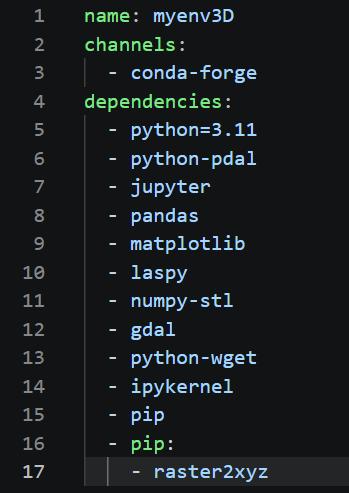

From the start menu, open the Anaconda Prompt:

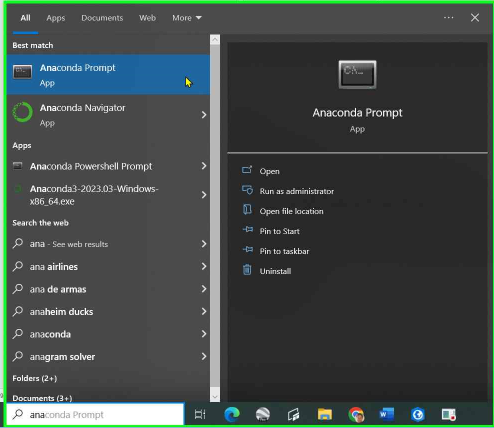

Enter the following commands: <br><br>
1. cd to the folder your .yml file is in <br>
`cd C:/Users/[name]/...` <br><br>
2. Run command to create environment <br>
`conda env create -f environment.yml` <br>
^ If this doesn't work run `conda env create -n myenv3D -f environment.yml` <br><br>
4. Activate environment <br>
`activate myenv3D` <br><br>
5. Register the environment as a Jupyter Kernel <br>
`python -m ipykernel install -–user -–name myenv3D -–display-name “Python (myenv3D)"` <br><br>
6. Open jupyter notebook <br>
`jupyter notebook`

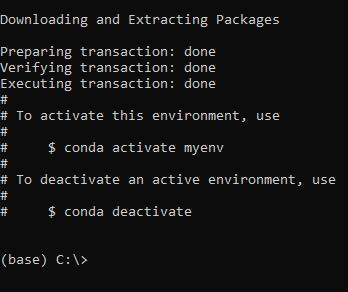

Once in Jupyter Notebook, import libraries: 

In [1]:
import pdal
import wget
import numpy as np
import laspy as lp
import json
import pandas as pd
import os
import matplotlib.pyplot as plt
import stl
from osgeo import gdal
from raster2xyz.raster2xyz import Raster2xyz
from mpl_toolkits.mplot3d import Axes3D
from stl import mesh
import matplotlib.tri as mtri

### If you have issues with the environment.yml file you can enter these commands into Anaconda Prompt instead:

`conda create --yes –name myenv3D –channel conda-forge python=3.11 python-pdal jupyter pandas matplotlib laspy numpy-stl gdal python-wget ipykernel` <br><br>
`conda activate myenv3D` <br><br>
`pip install raster2xyz` <br><br>
`python -m ipykernel install –user –name myenv3D –display-name “Python (myenv3D)"`<br><br>
`jupyter notebook` <br><br>


# Code:
---

# VRT to Points

## What you need to change

Before running the notebook, update the parameters below to match your area of interest

---

### Required Changes

**`inputVrt`** — The elevation data source(s) for your area.
The example uses NOAA NCEI CUDEM topobathy tiles for Hilo Bay, Hawaii.
Find your dataset at the [NOAA Digital Coast Data Access Viewer](https://coast.noaa.gov/dataviewer/).

**`crs`** — The projected coordinate system (in meters) for your location.
`EPSG:6628` is specific to the Hilo, Hawaii area.
Find the right EPSG code for your area at [epsg.io](https://epsg.io).
> ⚠️ Do not use a geographic (lat/lon) CRS here — the code assumes meters.

**`aoi_bounds`** — The bounding box of your area of interest: `[minX, minY, maxX, maxY]`
These must be in the same units as your `crs` (meters).
You can find these coordinates using [QGIS](https://qgis.org) or the NOAA Data Access Viewer.

---

### Optional Adjustments

**`vert_scale`** — Vertical exaggeration applied to the model.
`[[0.0, 1.0, 0.0, 10.0]]` multiplies elevation by 10x to make relief more visible when 3D printed.
Increase for flat areas (e.g. river deltas), decrease for dramatic terrain.

**`voxel_size`** — Controls the detail level of the model (in meters).
Smaller = more detail but a larger, slower-to-process STL file.
Start with `100` and decrease once you confirm the pipeline runs end to end. Please note that if you change the voxel_size you must also change the max_edge_length which is approximately 2x the voxel_size.

---

### Downloading Data
- Find the corresponding VRT file for the dataset through NOAA Data Access Viewer. The VRT is the virtual raster file that GDAL can use to access the elevation data.
- Copy the URL of the .vrt file.
- Add /vsicurl/ to the beginning of the URL when using it with GDAL.
  - This allows you to download the data without downloading to your PC.

`inputVrt = [ "/vsicurl/https://example.noaa.gov/path/to/elevation.vrt" ]`

If your area requires multiple elevation datasets, include multiple VRT URLs in the list:

---

### Data Attribution
This notebook uses **`NOAA NCEI CUDEM`** topobathy data, which is public domain.
If you publish models built from this data, attributing NOAA NCEI is appreciated.

In [2]:
from osgeo import gdal
gdal.UseExceptions()

#The website has been updated since initial model creation. This model pulls data from NOAA Data Access Viewer.
vrt = "aoi.vrt"
inputVrt = [
    "/vsicurl/https://chs.coast.noaa.gov/htdata/raster2/elevation/NCEI_third_Topobathy_Hawaii_9429/NCEI_third_Topobathy_Hawaii_EPSG-4326.vrt",
    "/vsicurl/https://chs.coast.noaa.gov/htdata/raster2/elevation/NCEI_ninth_Topobathy_Hawaii_9428/NCEI_ninth_Topobathy_Hawaii_EPSG-4326.vrt"
]

merge = gdal.BuildVRT(vrt, inputVrt)
del merge

dem = "dem.tif"
demScaled = "demScaled.tif"
crs = 'EPSG:6628'
aoi_bounds = [ 540000, 95900, 555500, 112300 ] #W,S,E,N
vert_scale = [[0.0, 1.0, 0.0, 10.0]]

convert = gdal.Warp(dem, vrt, outputBoundsSRS = crs, outputBounds = aoi_bounds, dstSRS = crs)
del convert

scale = gdal.Translate(demScaled, dem, scaleParams = vert_scale)
del scale
#scale = gdal.Translate(demScaled, dem, heightPct = 300)


In [3]:
#%pip install raster2xyz already installed with pandas
#input_raster = "3xVert.tif"

out_csv = "points.csv"

rtxyz = Raster2xyz()
rtxyz.translate(demScaled, out_csv)

point_cloud = pd.read_csv(out_csv)
points = np.vstack((point_cloud.x, point_cloud.y, point_cloud.z)).transpose()
print("Number of points in original file:",len(points))

dem = None
demScaled = None 

[2026-10-04 11:09:20 - INFO] - Getting geotransform and data...
[2026-10-04 11:09:20 - INFO] - Getting XYZ data...
[2026-10-04 11:09:20 - INFO] - Getting geotransformed coordinates...
[2026-10-04 11:09:20 - INFO] - Building XYZ data...
[2026-10-04 11:09:29 - INFO] - New XYZ (csv file) created...


Number of points in original file: 5777064


# Points to Mesh:

In [4]:
# Voxel_size needs to be adjusted if the area of interest changes! It controls the horizontal resolution of the final point cloud
# Smaller values retain more detail but produce more points and larger/more computationally expensive meshes.
voxel_size = 75   #Voxel size units in meters

nb_vox = np.ceil((np.max(points, axis=0) - np.min(points, axis=0))/voxel_size)
print("The voxel grid is X,Y,Z voxels:", (nb_vox))

The voxel grid is X,Y,Z voxels: [207. 219. 102.]


In [5]:
nb_vox_readout = np.prod(nb_vox, dtype=int) 
print("This will reduce number of points to", nb_vox_readout)

pts_length = len(points)
perct = ((1-(nb_vox_readout/pts_length))*100)
print("Or reduce by", perct, "%")

This will reduce number of points to 4623966
Or reduce by 19.95993120380871 %


In [6]:
# Do not run below line for LIDAR Data.
points = np.vstack((point_cloud.x, point_cloud.y, point_cloud.z)).transpose()
grid_sample_pc_np = np.array(points)

In [7]:
#Define a function that takes as input an array of points, and a voxel size expressed in meters. It returns the sampled point cloud
def grid_subsampling(points, voxel_size):

  nb_vox=np.ceil((np.max(points, axis=0) - np.min(points, axis=0))/voxel_size)
  non_empty_voxel_keys, inverse, nb_pts_per_voxel= np.unique(((points - np.min(points, axis=0)) // voxel_size).astype(int), axis=0, return_inverse=True, return_counts=True)
  idx_pts_vox_sorted=np.argsort(inverse)
  voxel_grid={}
  grid_barycenter,grid_candidate_center=[],[]
  last_seen=0

  for idx,vox in enumerate(non_empty_voxel_keys):
    voxel_grid[tuple(vox)]=points[idx_pts_vox_sorted[last_seen:last_seen+nb_pts_per_voxel[idx]]]
    grid_barycenter.append(np.mean(voxel_grid[tuple(vox)],axis=0))
    grid_candidate_center.append(voxel_grid[tuple(vox)][np.linalg.norm(voxel_grid[tuple(vox)]-np.mean(voxel_grid[tuple(vox)],axis=0),axis=1).argmin()])
    last_seen+=nb_pts_per_voxel[idx]

  return grid_candidate_center

In [8]:
grid_sampled_point_cloud = grid_subsampling(points, voxel_size)

In [9]:
grid_sample_pc_np = np.array(grid_sampled_point_cloud)

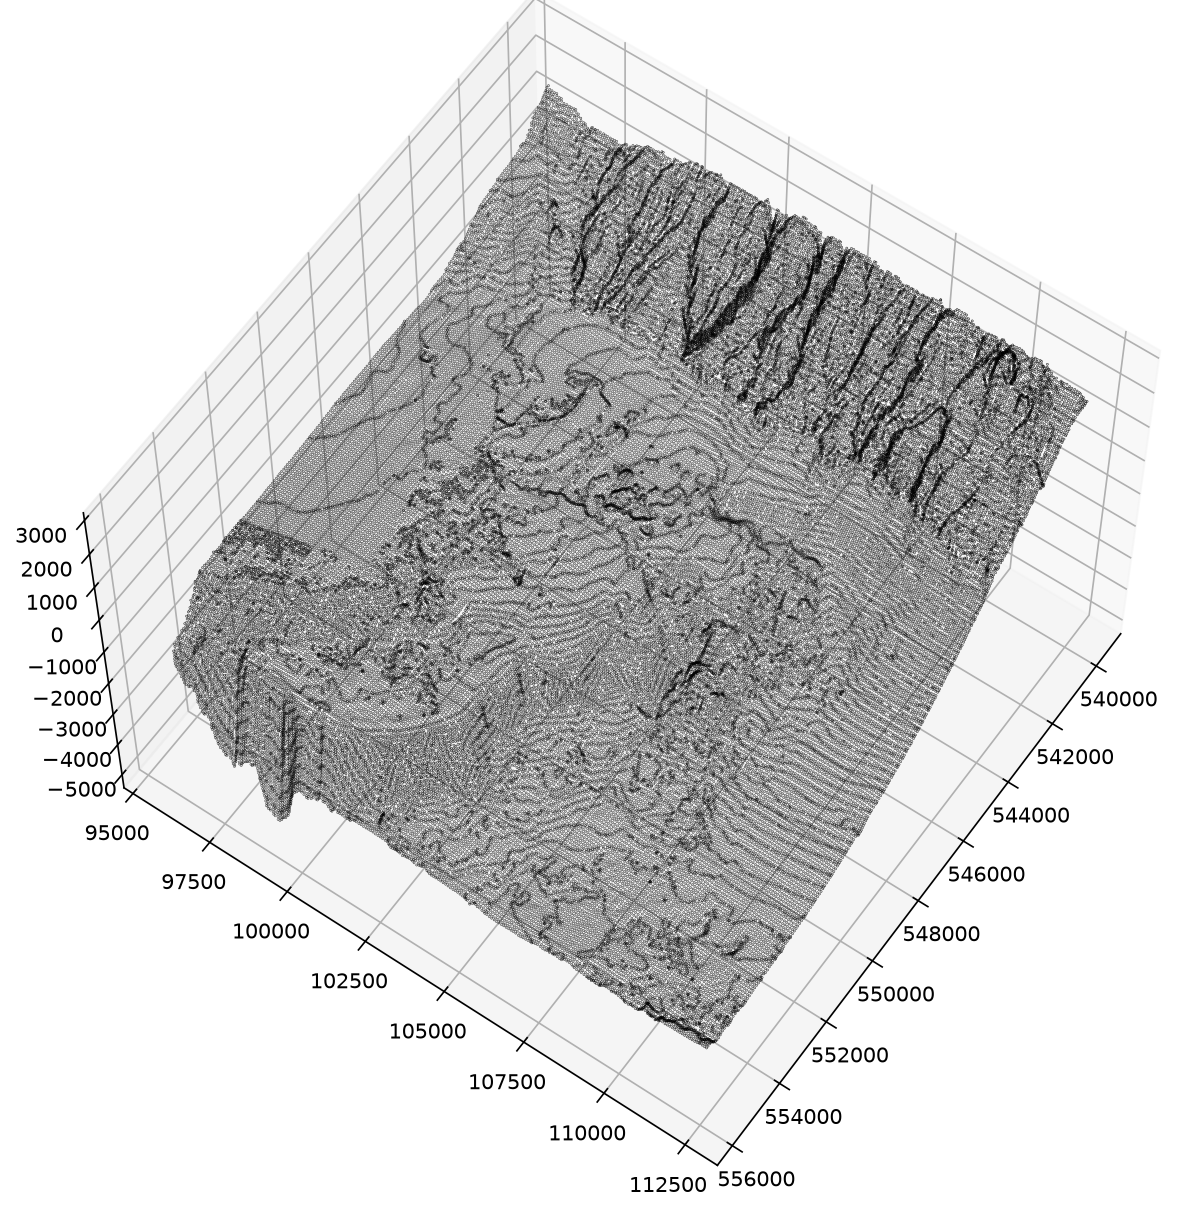

In [10]:
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d

from matplotlib.pyplot import figure
figure(figsize=(12, 10), dpi=150)

ax = plt.axes(projection='3d')
ax.scatter(grid_sample_pc_np[:,0], grid_sample_pc_np[:,1], grid_sample_pc_np[:,2], s = 0.05, c = 'black')
ax.view_init(60, 35)
plt.show()

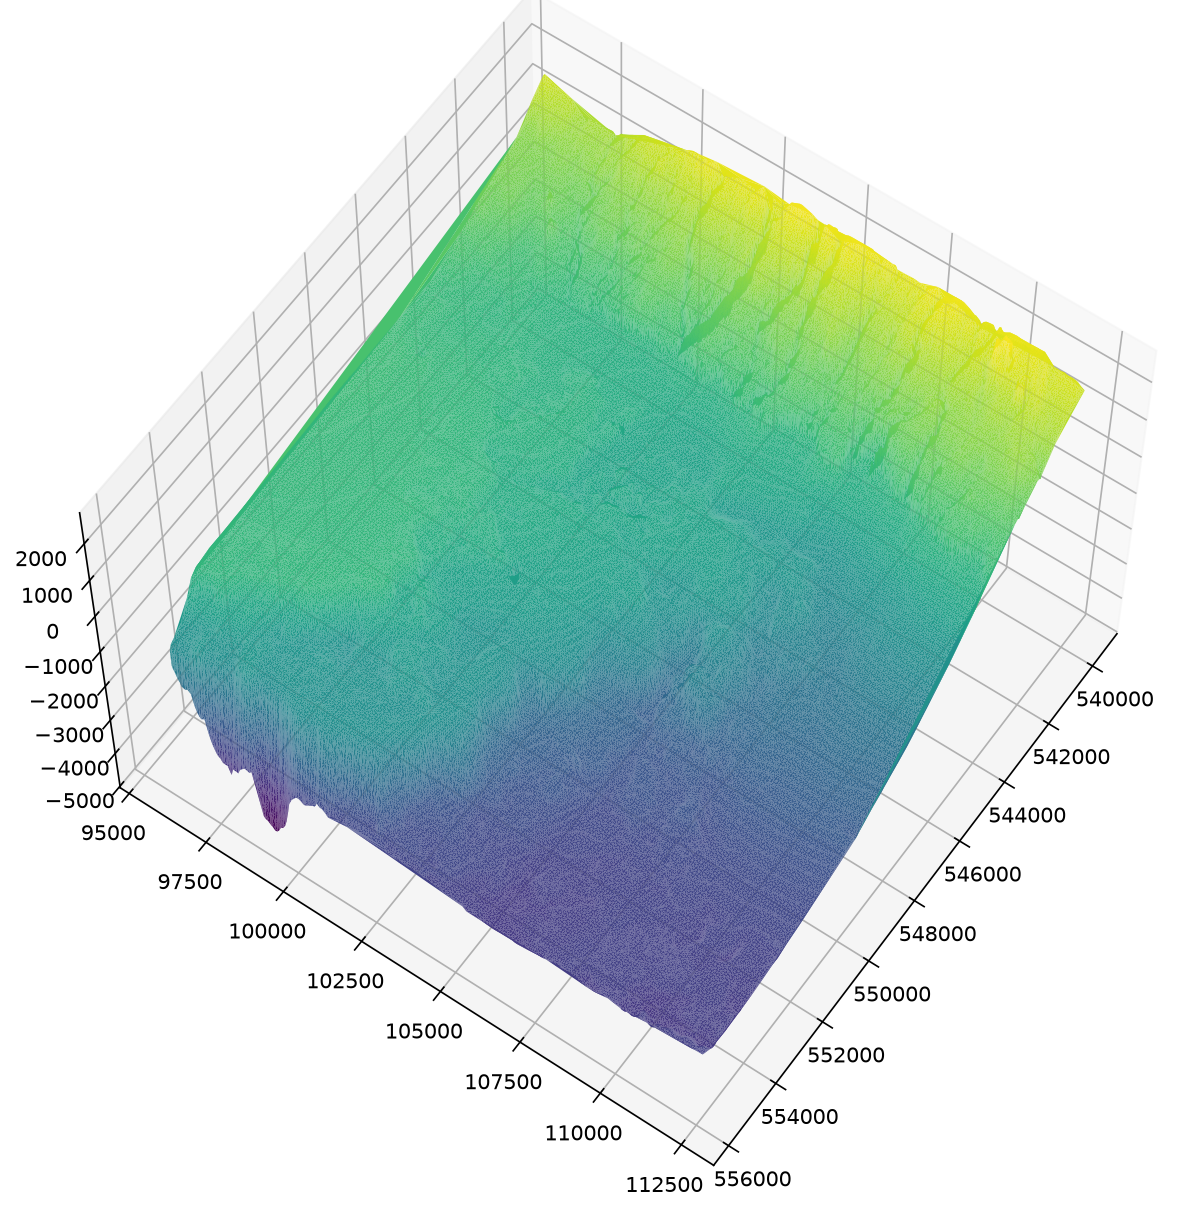

In [11]:
from matplotlib.pyplot import figure
figure(figsize=(12, 10), dpi=150)

ax = plt.axes(projection='3d')
trisurf = ax.plot_trisurf(grid_sample_pc_np[:,0], grid_sample_pc_np[:,1], grid_sample_pc_np[:,2], 
                ax.view_init(60, 35), cmap='viridis', edgecolor='none');

In [12]:
import matplotlib.tri as mtri

x_all = grid_sample_pc_np[:,0]
y_all = grid_sample_pc_np[:,1]
z_all = grid_sample_pc_np[:,2]

tris = mtri.Triangulation(x_all, y_all)

data = np.zeros(len(tris.triangles), dtype=mesh.Mesh.dtype)
m = mesh.Mesh(data, remove_empty_areas=False)
m.x[:] = x_all[tris.triangles]
m.y[:] = y_all[tris.triangles]
m.z[:] = z_all[tris.triangles]

m.save('point_cloud_model3D_1.stl')

# Base

Skip to combining base for LIDAR Data. (Run otherwise!)

In [13]:
demScaled = "demScaled.tif"

ds = gdal.Open(demScaled)
srcband = ds.GetRasterBand(1)
srcband.ComputeStatistics(0)

# General baseElev code : defines base as always 10% of the terrain relief below the lowest point.
min_elev = srcband.GetMinimum()
max_elev = srcband.GetMaximum()
baseElev = min_elev - 0.10 * (max_elev - min_elev)

#baseElev = ((srcband.GetMinimum()) * 0.1) + srcband.GetMinimum() <- Hilo-Specific Code

info = gdal.Info(demScaled, format = 'json')
coords = json.dumps(info)
data = json.loads(coords)
uL = data["cornerCoordinates"]["upperLeft"]
uL.append(baseElev)
lL = data["cornerCoordinates"]["lowerLeft"]
lL.append(baseElev)
lR = data["cornerCoordinates"]["lowerRight"]
lR.append(baseElev)
uR = data["cornerCoordinates"]["upperRight"]
uR.append(baseElev)
baseCoords = np.vstack((uL, lL, lR, uR))

print(baseCoords)

"""
x_all = baseCoords[:,0]
y_all = baseCoords[:,1]
z_all = baseCoords[:,2]

tris = mtri.Triangulation(x_all, y_all)

data = np.zeros(len(tris.triangles), dtype=mesh.Mesh.dtype)
m = mesh.Mesh(data, remove_empty_areas=False)
m.x[:] = x_all[tris.triangles]
m.y[:] = y_all[tris.triangles]
m.z[:] = z_all[tris.triangles]

m.save('base.stl')
"""

"""
from matplotlib.pyplot import figure
figure(figsize=(12, 10), dpi=150)

ax = plt.axes(projection='3d')
trisurf = ax.plot_trisurf(baseCoords[:,0], baseCoords[:,1], baseCoords[:,2], 
                ax.view_init(60, 35), cmap='viridis', edgecolor='none');
"""


[[540000.         112300.          -5694.99353027]
 [540000.          95900.          -5694.99353027]
 [555500.          95900.          -5694.99353027]
 [555500.         112300.          -5694.99353027]]


"\nfrom matplotlib.pyplot import figure\nfigure(figsize=(12, 10), dpi=150)\n\nax = plt.axes(projection='3d')\ntrisurf = ax.plot_trisurf(baseCoords[:,0], baseCoords[:,1], baseCoords[:,2], \n                ax.view_init(60, 35), cmap='viridis', edgecolor='none');\n"

In [14]:
# Save final combined model directly - no need to merge separate files
output_dir = os.path.join(os.getcwd(), "output")
os.makedirs(output_dir, exist_ok=True)

save_path = os.path.join(output_dir, "combined_model.stl")

combined_cloud = np.vstack((grid_sample_pc_np, baseCoords))

x_all = combined_cloud[:, 0]
y_all = combined_cloud[:, 1]
z_all = combined_cloud[:, 2]

tris = mtri.Triangulation(x_all, y_all)

data = np.zeros(len(tris.triangles), dtype=mesh.Mesh.dtype)
m = mesh.Mesh(data, remove_empty_areas=False)
m.x[:] = x_all[tris.triangles]
m.y[:] = y_all[tris.triangles]
m.z[:] = z_all[tris.triangles]

m.save(save_path, mode=stl.Mode.ASCII)
print("Saved to:", save_path)

Saved to: C:\Users\mccoy\Documents\3DWorkshop\3dModel-main\output\combined_model.stl


### Combining base array with model array

If you change the voxel_size you also need to change the max_edge_length in this section!

Start running base section for LIDAR here.

In [15]:
import matplotlib.tri as mtri
import numpy as np
from stl import mesh
import stl

max_edge_length = 150  # tune to ~2x your voxel_size

# ── 1. TERRAIN ───────────────────────────────────────────────────────────────
tris = mtri.Triangulation(grid_sample_pc_np[:,0], grid_sample_pc_np[:,1])
pts2d = np.column_stack([grid_sample_pc_np[:,0], grid_sample_pc_np[:,1]])
keep = []
for tri in tris.triangles:
    a, b, c = pts2d[tri[0]], pts2d[tri[1]], pts2d[tri[2]]
    if max(np.linalg.norm(a-b), np.linalg.norm(b-c), np.linalg.norm(c-a)) <= max_edge_length:
        keep.append(tri)
keep = np.array(keep)

x, y, z = grid_sample_pc_np[:,0], grid_sample_pc_np[:,1], grid_sample_pc_np[:,2]
terrain_data = np.zeros(len(keep), dtype=mesh.Mesh.dtype)
terrain_mesh = mesh.Mesh(terrain_data, remove_empty_areas=False)
terrain_mesh.x[:] = x[keep]; terrain_mesh.y[:] = y[keep]; terrain_mesh.z[:] = z[keep]
print(f"Terrain: {len(keep)} triangles")

# ── 2. BOUNDARY DETECTION ────────────────────────────────────────────────────
minX, maxX = float(np.min(x)), float(np.max(x))
minY, maxY = float(np.min(y)), float(np.max(y))
base_elev = float(baseCoords[0, 2])

edge_count = {}
for tri in keep:
    for e in [(tri[0],tri[1]),(tri[1],tri[2]),(tri[2],tri[0])]:
        k = tuple(sorted(e)); edge_count[k] = edge_count.get(k, 0) + 1
boundary_edges = [e for e, c in edge_count.items() if c == 1]

tolerance = voxel_size * 1.5
perimeter_edges = [(i,j) for i,j in boundary_edges
    if min((x[i]+x[j])/2-minX, maxX-(x[i]+x[j])/2,
           (y[i]+y[j])/2-minY, maxY-(y[i]+y[j])/2) < tolerance]

# ── 3. PER-VERTEX SNAPPING ───────────────────────────────────────────────────
# Snap each vertex to the nearest wall face based on its own position —
# NOT the edge midpoint. This ensures consecutive boundary edges sharing
# a vertex produce matching seam geometry.
outer_verts = set()
for i, j in perimeter_edges:
    outer_verts.add(i); outer_verts.add(j)

vertex_snap = {}; vertex_face = {}
for idx in outer_verts:
    px, py, pz = float(x[idx]), float(y[idx]), float(z[idx])
    d = [px-minX, maxX-px, py-minY, maxY-py]; nearest = min(d)
    if   d[0] == nearest: vertex_snap[idx]=[minX,py,pz]; vertex_face[idx]='left'
    elif d[1] == nearest: vertex_snap[idx]=[maxX,py,pz]; vertex_face[idx]='right'
    elif d[2] == nearest: vertex_snap[idx]=[px,minY,pz]; vertex_face[idx]='bottom'
    else:                 vertex_snap[idx]=[px,maxY,pz]; vertex_face[idx]='top'

# ── 4. SEAMS + WALLS ─────────────────────────────────────────────────────────
# For each perimeter edge:
#   - Seam quad: fills sliver gap between original terrain edge and snapped wall top
#   - Wall quad: vertical face from snapped top down to base
all_tris = []; wall_bottom_pts = set(); wall_snapped_all = []

for i, j in perimeter_edges:
    oi = [float(x[i]),float(y[i]),float(z[i])]; oj = [float(x[j]),float(y[j]),float(z[j])]
    si = vertex_snap[i]; sj = vertex_snap[j]
    si_b = [si[0],si[1],base_elev]; sj_b = [sj[0],sj[1],base_elev]

    # Seam
    all_tris.append([oi, oj, sj]); all_tris.append([oi, sj, si])
    # Wall
    all_tris.append([si, sj, sj_b]); all_tris.append([si, sj_b, si_b])

    wall_bottom_pts.add((si[0],si[1])); wall_bottom_pts.add((sj[0],sj[1]))
    wall_snapped_all.extend([si, sj])

# ── 5. CORNER FILLS ──────────────────────────────────────────────────────────
# Angle-sorted fan from each base corner to all nearby snapped wall points,
# bridging the gap between adjacent wall faces at corners.
BL=[minX,minY,base_elev]; BR=[maxX,minY,base_elev]
TL=[minX,maxY,base_elev]; TR=[maxX,maxY,base_elev]
corner_radius = voxel_size * 2
wall_snapped_all = list({tuple(p): p for p in wall_snapped_all}.values())

def near_corner(pts, cx, cy):
    return [p for p in pts if abs(p[0]-cx) < corner_radius and abs(p[1]-cy) < corner_radius]

def fill_corner(corner_xyz, nearby_pts):
    if len(nearby_pts) < 2: return
    cx, cy = corner_xyz[0], corner_xyz[1]
    sorted_pts = sorted(nearby_pts, key=lambda p: np.arctan2(p[1]-cy, p[0]-cx))
    for k in range(len(sorted_pts)-1):
        all_tris.append([corner_xyz, sorted_pts[k], sorted_pts[k+1]])

fill_corner(BL, near_corner(wall_snapped_all, minX, minY))
fill_corner(BR, near_corner(wall_snapped_all, maxX, minY))
fill_corner(TL, near_corner(wall_snapped_all, minX, maxY))
fill_corner(TR, near_corner(wall_snapped_all, maxX, maxY))

# ── 6. TRIANGULATED BASE ─────────────────────────────────────────────────────
# Build base from ALL wall bottom points so its boundary edges match the wall
# bottoms exactly — no edge mismatch between wall quads and base plate.
wall_bottom_pts.update([(minX,minY),(maxX,minY),(minX,maxY),(maxX,maxY)])
base_2d = np.array(list(wall_bottom_pts))
base_tri_obj = mtri.Triangulation(base_2d[:,0], base_2d[:,1])
base_data = np.zeros(len(base_tri_obj.triangles), dtype=mesh.Mesh.dtype)
base_mesh = mesh.Mesh(base_data, remove_empty_areas=False)
base_mesh.x[:] = base_2d[:,0][base_tri_obj.triangles]
base_mesh.y[:] = base_2d[:,1][base_tri_obj.triangles]
base_mesh.z[:] = np.full(len(base_tri_obj.triangles)*3, base_elev).reshape(-1,3)
print(f"Base: {len(base_tri_obj.triangles)} triangles")

all_tris = np.array(all_tris)
wall_data_arr = np.zeros(len(all_tris), dtype=mesh.Mesh.dtype)
wall_mesh = mesh.Mesh(wall_data_arr, remove_empty_areas=False)
wall_mesh.x[:] = all_tris[:,:,0]; wall_mesh.y[:] = all_tris[:,:,1]; wall_mesh.z[:] = all_tris[:,:,2]
print(f"Walls + seams + corners: {len(all_tris)} triangles")

# ── 7. COMBINE AND SAVE ──────────────────────────────────────────────────────
combined = mesh.Mesh(np.concatenate([terrain_mesh.data, base_mesh.data, wall_mesh.data]))
combined.save('combined_model.stl', mode=stl.Mode.ASCII)
print(f"\nSaved: combined_model.stl")
print(f"Total triangles: {len(combined.data)}")

# ── 8. WATERTIGHT VERIFICATION ───────────────────────────────────────────────
# Checks every edge to see if it's shared by exactly 2 triangles.
# Open edges (count != 2) indicate gaps.
# Distinguishes between:
#   - Interior holes: open terrain over water/bay — expected, slicers handle these
#   - Exterior shell gaps: holes in the outer solid block — need repair before printing
print("\n── Watertight check ───────────────────────────────────────────")
edge_tally = {}
for tri in combined.data:
    verts = [tuple(np.round(v, 2)) for v in tri['vectors']]
    for edge in [(verts[0],verts[1]),(verts[1],verts[2]),(verts[2],verts[0])]:
        k = tuple(sorted(edge)); edge_tally[k] = edge_tally.get(k, 0) + 1

open_edges = [(e, c) for e, c in edge_tally.items() if c != 2]
eps = 1.0  # tolerance in metres for classifying boundary edges
exterior_open = 0; interior_open = 0

for e, c in open_edges:
    on_wall = any(abs(v[0]-minX)<eps or abs(v[0]-maxX)<eps or
                  abs(v[1]-minY)<eps or abs(v[1]-maxY)<eps for v in e)
    if on_wall: exterior_open += 1
    else:       interior_open += 1

if interior_open > 0:
    print(f"  ℹ {interior_open} interior open edges (open water / bay area — expected, slicers handle these)")
if exterior_open == 0:
    print("  ✓ Outer shell is fully closed — safe to send to 3D printer")
else:
    print(f"  ✗ {exterior_open} gaps in outer shell — run repair before printing")
    print()
    print("  Recommended repair options (free, one-click):")
    print("  • PrusaSlicer: File → Import → STL → Repair button in print settings")
    print("  • Microsoft 3D Builder: Open file → Repair (prompted automatically) <- No longer supported by Microsoft")
    print("  • Meshmixer: Analysis → Inspector → Auto Repair All")

Terrain: 166698 triangles
Base: 780 triangles
Walls + seams + corners: 3122 triangles

Saved: combined_model.stl
Total triangles: 170600

── Watertight check ───────────────────────────────────────────
  ✗ 170 gaps in outer shell — run repair before printing

  Recommended repair options (free, one-click):
  • PrusaSlicer: File → Import → STL → Repair button in print settings
  • Microsoft 3D Builder: Open file → Repair (prompted automatically) <- No longer supported by Microsoft
  • Meshmixer: Analysis → Inspector → Auto Repair All


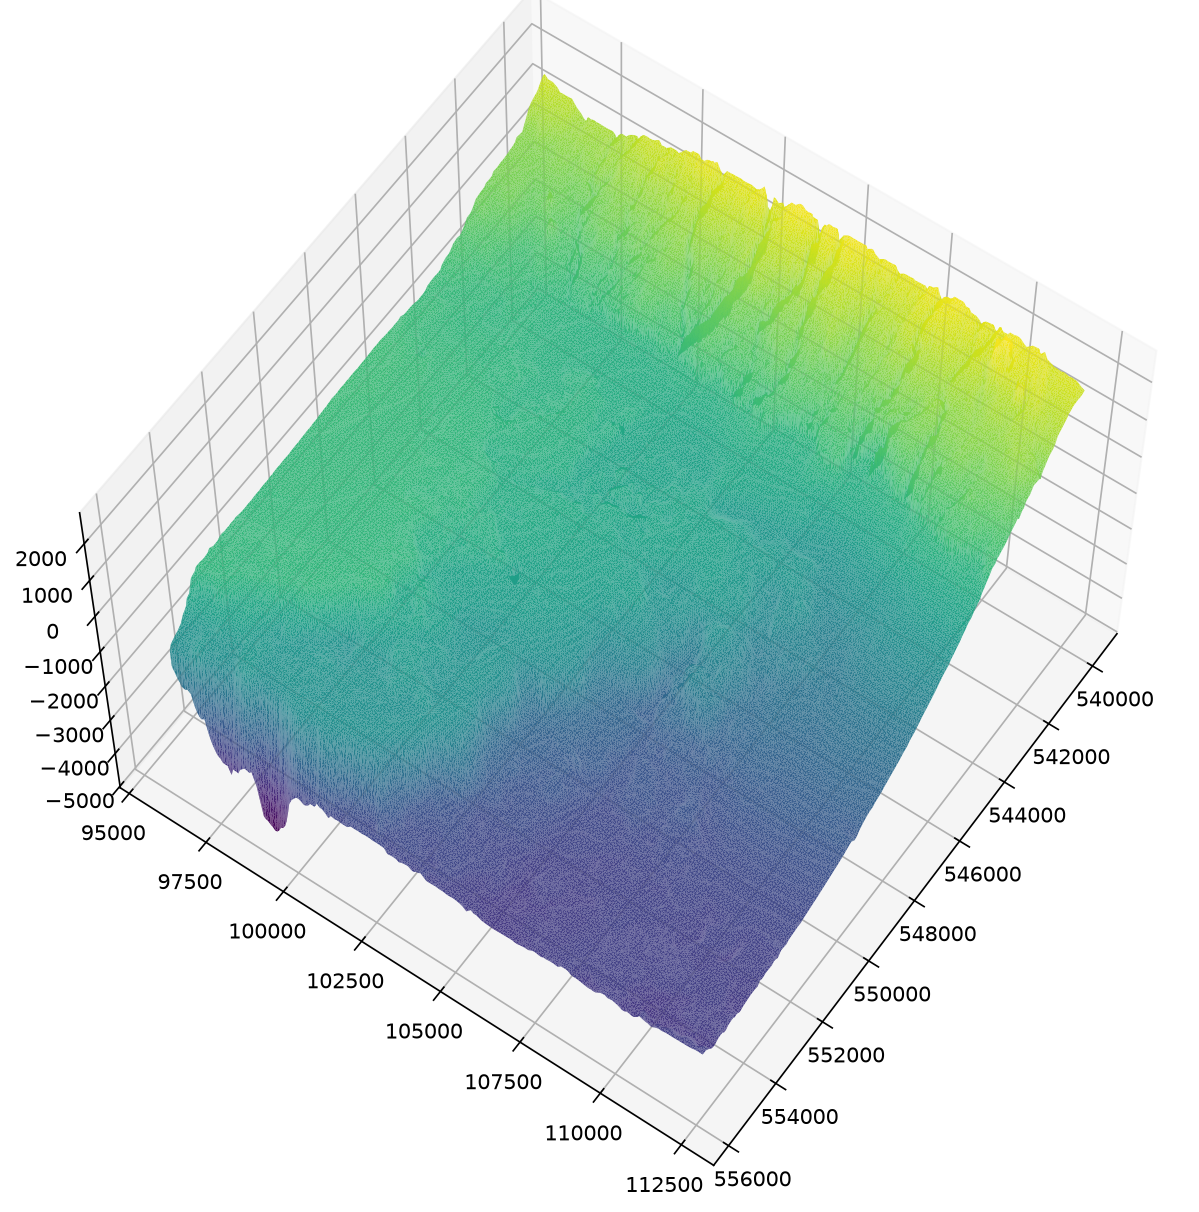

In [16]:
from matplotlib.pyplot import figure
figure(figsize=(12, 10), dpi=150)

ax = plt.axes(projection='3d')
ax.view_init(60, 35)
ax.plot_trisurf(
    grid_sample_pc_np[:,0],
    grid_sample_pc_np[:,1],
    grid_sample_pc_np[:,2],
    triangles=keep,
    cmap='viridis',
    edgecolor='none'
)
plt.show()

# Optional: Processing Lidar Points:

## Merge laz files, filter, and reproject

This section is an **alternative** to the NOAA raster workflow above.
Use it if you have your own raw lidar files (`.laz`/`.las`) instead of
pulling from NOAA's hosted rasters.

**You do not need to run this if you used the NOAA VRT approach above.**

This workflow assumes that your LiDAR data:
- are already classified,
- contain ground points classified as ASPRS Class 2,
- have a known coordinate reference system (CRS), and
- cover the area you want to model.

Before running, update:
- `LIDAR_INPUT` — path to your `.laz` files
- `IN_CRS` - CRS of your LiDAR data
- `OUT_CRS` — CRS you want to use for your model
- The `POLYGON` in the clip step — your area of interest boundary in WKT format

To find WKT polygon coordinates for your area, use
[QGIS](https://qgis.org) or the
[NOAA Data Access Viewer](https://coast.noaa.gov/dataviewer/).

## LiDAR WORKFLOW
- Import Libraries
- SKIP VRT To Points Section
- Run this LiDAR Section Below
- Run Points to Mesh Section
  - Skip the NOAA-specific line below because `point_cloud` is only created by the NOAA workflow:
  - `points = np.vstack((point_cloud.x, point_cloud.y, point_cloud.z)).transpose()`
  - Continue running the rest of the Points to Mesh section normally.
- Skip DEM Base Section
  - `baseCoords` has already been created above from the LiDAR data.
- Run "Combining base array with model array"
- Run rest of code to create stl file

In [ ]:
# Update paths, CRS, and polygon for your own dataset before running.

LIDAR_INPUT = "path/to/your/lidar/*.laz"   # update this to your filepath
MERGED_LAS  = "outputMergePrj.las"
CLIPPED_LAS = "points.las"

# Example CRS for the Hilo Bay dataset:
# Replace these values if you are using a different LiDAR dataset.
IN_CRS      = "EPSG:6322"   # update to match your lidar data
OUT_CRS     = "EPSG:6630"   # update to match your area

pipeline_merge = {
    "pipeline": [
        LIDAR_INPUT,
        {"type": "filters.range", "limits": "Classification[2:2]"},
        {"type": "filters.reprojection", "in_srs": IN_CRS, "out_srs": OUT_CRS},
        {"type": "writers.las",
         "scale_x":"0.0001","scale_y":"0.0001","scale_z":"0.01",
         "offset_x":"auto","offset_y":"auto","offset_z":"auto",
         "filename": MERGED_LAS},
    ]
}
# To run this pipeline: remove the `#` from the two execution lines below.
# pipeline = pdal.Pipeline(json.dumps(pipeline_merge))
# pipeline.execute()

pipeline_clip = {
    "pipeline": [
        MERGED_LAS,
        {"type": "filters.crop",
         "polygon": "POLYGON((...))"},  # update with your AOI boundary
        CLIPPED_LAS,
    ]
}

# To run this pipeline: remove the `#` from the two execution lines below.
# pipeline = pdal.Pipeline(json.dumps(pipeline_clip))
# pipeline.execute()

# Read clipped LiDAR points
las = lp.read(CLIPPED_LAS)

points = np.column_stack((las.x, las.y, las.z))

print("Number of LiDAR points:", len(points))

# Create model base coordinates from LiDAR extent

minX = np.min(points[:, 0])
maxX = np.max(points[:, 0])
minY = np.min(points[:, 1])
maxY = np.max(points[:, 1])

# Note: Functional, but can potentially make a weirdly deep base if there's a single very low LiDAR point.
base_elev = np.min(points[:, 2])

baseCoords = np.array([
    [minX, maxY, base_elev],
    [minX, minY, base_elev],
    [maxX, minY, base_elev],
    [maxX, maxY, base_elev]
])

print("LiDAR model extent:")
print("X:", minX, "to", maxX)
print("Y:", minY, "to", maxY)
print("Base elevation:", base_elev)